In [7]:
import pandas as pd

# Load your files (adjust paths if necessary)
metadata_df = pd.read_csv("Zomato Restaurant names and Metadata.csv")
reviews_df = pd.read_csv("Zomato Restaurant reviews.csv")

# Merge based on restaurant names
merged_df = pd.merge(
    reviews_df, metadata_df,
    left_on="Restaurant", right_on="Name",
    how="inner"
)

# Drop the redundant 'Name' column
merged_df.drop(columns=["Name"], inplace=True)

# Save to new CSV
merged_df.to_csv("Zomato_Merged_Metadata_Reviews.csv", index=False)
print("✅ Merged file saved as 'Zomato_Merged_Metadata_Reviews.csv'")


✅ Merged file saved as 'Zomato_Merged_Metadata_Reviews.csv'


🔥 Top Value-for-Money Cuisine + Cost Tier Combos:
        Cuisines Cost_Tier    Rating        Cost  Benefit_Ratio
6        Arabian       Low  2.990000  150.000000       0.019933
55         Momos       Low  3.725000  200.000000       0.018625
41     Ice Cream       Low  3.892500  250.000000       0.015570
9          Asian       Low  2.580000  200.000000       0.012900
50      Lebanese       Low  3.430000  300.000000       0.011433
72   Street Food       Low  3.120000  275.000000       0.011345
29      Desserts       Low  3.830000  341.666667       0.011210
15     Beverages       Low  3.850000  350.000000       0.011000
12        Bakery       Low  3.794314  350.000000       0.010841
33     Fast Food       Low  3.272143  385.714286       0.008483
63         Pizza       Low  3.090000  400.000000       0.007725
1       American       Low  3.770000  500.000000       0.007540
76         Wraps       Low  3.580000  500.000000       0.007160
61  North Indian       Low  3.224000  460.000000      

C:\Users\sonu\AppData\Local\Temp\ipykernel_3652\4210027428.py:49: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\New folder\python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


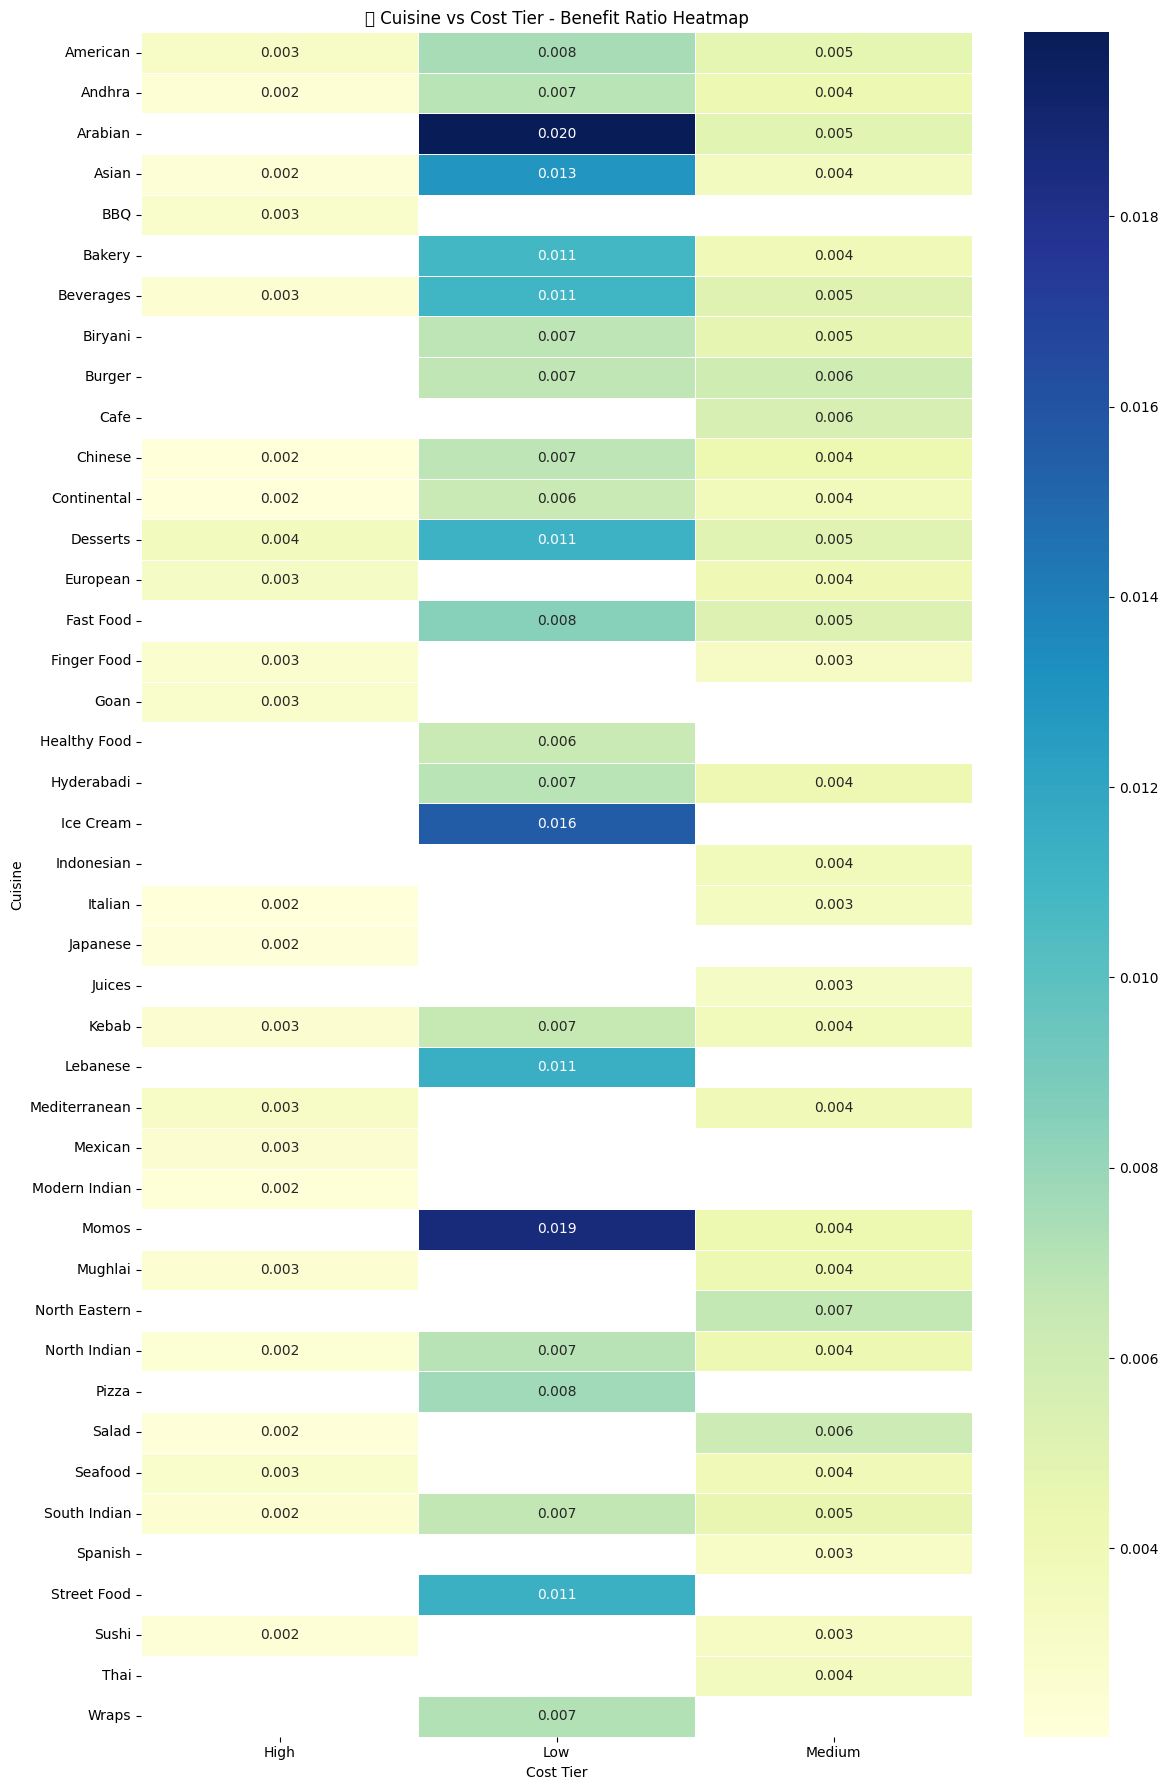

In [18]:
import pandas as pd

# Load merged sentiment data
df = pd.read_csv("Zomato_Merged_Sentiment_Analysis.csv")

# Clean 'Cost' and 'Rating'
df['Cost'] = df['Cost'].astype(str).str.replace(",", "").astype(float)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# --- COST TIER ---
def cost_bucket(cost):
    if cost <= 500:
        return "Low"
    elif cost <= 1200:
        return "Medium"
    else:
        return "High"

df['Cost_Tier'] = df['Cost'].apply(cost_bucket)

# --- CUISINE EXPLOSION ---
df['Cuisines'] = df['Cuisines'].fillna("").str.split(", ")
exploded_df = df.explode('Cuisines')
exploded_df['Cuisines'] = exploded_df['Cuisines'].str.strip()

# --- Group by Cuisine + Cost_Tier ---
grouped = exploded_df.groupby(['Cuisines', 'Cost_Tier']).agg({
    'Rating': 'mean',
    'Cost': 'mean'
}).reset_index()

# Benefit Ratio
grouped['Benefit_Ratio'] = grouped['Rating'] / grouped['Cost']

# Sort to see top value combos
top_value = grouped.sort_values(by='Benefit_Ratio', ascending=False)

print(" Top Value-for-Money Cuisine + Cost Tier Combos:")
print(top_value[['Cuisines', 'Cost_Tier', 'Rating', 'Cost', 'Benefit_Ratio']].head(15))
# Pivot for heatmap
pivot_df = grouped.pivot(index="Cuisines", columns="Cost_Tier", values="Benefit_Ratio")


plt.figure(figsize=(12, 18))
sns.heatmap(pivot_df, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=.5)
plt.title(" Cuisine vs Cost Tier - Benefit Ratio Heatmap")
plt.xlabel("Cost Tier")
plt.ylabel("Cuisine")
plt.tight_layout()
plt.show()


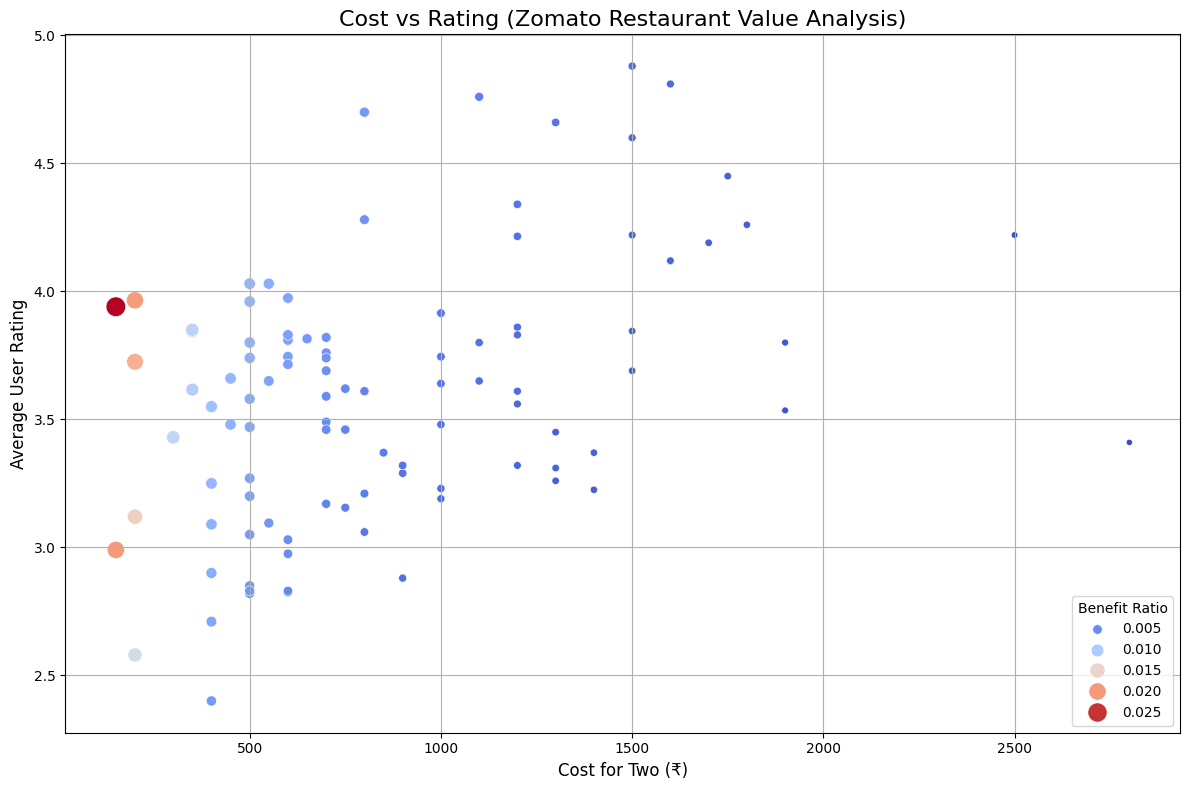

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Zomato_Merged_Sentiment_Analysis.csv")

# Clean 'Cost' and 'Rating'
df['Cost'] = df['Cost'].astype(str).str.replace(",", "").astype(float)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Group by restaurant to get one entry per restaurant
summary_df = df.groupby('Restaurant').agg({
    'Cost': 'first',
    'Rating': 'mean'
}).reset_index()

# Calculate benefit ratio
summary_df['Benefit_Ratio'] = summary_df['Rating'] / summary_df['Cost']

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=summary_df,
    x='Cost',
    y='Rating',
    size='Benefit_Ratio',
    hue='Benefit_Ratio',
    palette='coolwarm',
    legend='brief',
    sizes=(20, 200)
)

plt.title('Cost vs Rating (Zomato Restaurant Value Analysis)', fontsize=16)
plt.xlabel('Cost for Two (₹)', fontsize=12)
plt.ylabel('Average User Rating', fontsize=12)
plt.grid(True)
plt.legend(title='Benefit Ratio', loc='lower right')
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Load the dataset
df = pd.read_csv("Merged_Zomato_Data.csv")

# Drop rows with missing values in Review or Rating
df = df[['Review', 'Rating']].dropna()

# Clean the review text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

df['cleaned_review'] = df['Review'].apply(clean_text)

# Convert Rating to float and create sentiment label
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df = df.dropna(subset=['Rating'])
df['Sentiment'] = (df['Rating'] >= 3.5).astype(int)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_review'], df['Sentiment'], test_size=0.2, random_state=42)

# Vectorize text
vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train logistic regression
model = LogisticRegression()
model.fit(X_train_vec, y_train)

# Predict and show report
y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.78      0.81       734
           1       0.88      0.91      0.89      1257

    accuracy                           0.86      1991
   macro avg       0.86      0.85      0.85      1991
weighted avg       0.86      0.86      0.86      1991



In [10]:
# Step 1: Import necessary libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load the dataset
df = pd.read_csv("Merged_Zomato_Data.csv")

# Step 3: Clean and standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# Optional: Print to check exact column names
print("Available columns:\n", df.columns.tolist())

# Step 4: Select only required columns and drop NaN rows
required_columns = ['name', 'cuisines', 'approx_cost_for_two_people', 'aggregate_rating']
df_cluster = df[required_columns].dropna()

# Step 5: Convert cost to numeric (if needed)
df_cluster['approx_cost_for_two_people'] = df_cluster['approx_cost_for_two_people'].replace('[\₹,]', '', regex=True)
df_cluster['approx_cost_for_two_people'] = pd.to_numeric(df_cluster['approx_cost_for_two_people'], errors='coerce')
df_cluster = df_cluster.dropna()

# Step 6: Scale the features for clustering
scaler = StandardScaler()
df_cluster['cost_scaled'] = scaler.fit_transform(df_cluster[['approx_cost_for_two_people']])
df_cluster['rating_scaled'] = scaler.fit_transform(df_cluster[['aggregate_rating']])

# Step 7: Perform KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(df_cluster[['cost_scaled', 'rating_scaled']])

# Step 8: Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster,
    x='approx_cost_for_two_people',
    y='aggregate_rating',
    hue='cluster',
    palette='Set2'
)
plt.title("Zomato Restaurants Clustered by Cost and Rating")
plt.xlabel("Approximate Cost for Two")
plt.ylabel("Aggregate Rating")
plt.grid(True)
plt.show()

# Step 9: See few results
print(df_cluster[['name', 'cuisines', 'approx_cost_for_two_people', 'aggregate_rating', 'cluster']].head(10))


Available columns:
 ['name', 'links', 'cost', 'collections', 'cuisines', 'timings', 'restaurant', 'reviewer', 'review', 'rating', 'metadata', 'time', 'pictures']


KeyError: "['approx_cost_for_two_people', 'aggregate_rating'] not in index"

In [13]:
pip install textblob



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd
from textblob import TextBlob

# Load merged CSV
df = pd.read_csv("Zomato_Merged_Metadata_Reviews.csv")

# Perform sentiment analysis
df['Sentiment_Polarity'] = df['Review'].apply(lambda text: TextBlob(str(text)).sentiment.polarity)
df['Sentiment_Subjectivity'] = df['Review'].apply(lambda text: TextBlob(str(text)).sentiment.subjectivity)

# Categorize sentiment
def get_sentiment_category(polarity):
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment_Category'] = df['Sentiment_Polarity'].apply(get_sentiment_category)

# Save result
df.to_csv("Zomato_Merged_Sentiment_Analysis.csv", index=False)

# Preview
print(df[['Restaurant', 'Review', 'Sentiment_Category']].head())


        Restaurant                                             Review  \
0  Beyond Flavours  The ambience was good, food was quite good . h...   
1  Beyond Flavours  Ambience is too good for a pleasant evening. S...   
2  Beyond Flavours  A must try.. great food great ambience. Thnx f...   
3  Beyond Flavours  Soumen das and Arun was a great guy. Only beca...   
4  Beyond Flavours  Food is good.we ordered Kodi drumsticks and ba...   

  Sentiment_Category  
0           Positive  
1           Positive  
2           Positive  
3           Positive  
4           Positive  


 Top 15 Restaurants Loved by Customers:
                                 Restaurant  Num_Reviews  Avg_Rating  \
3                 AB's - Absolute Barbecues          100       4.880   
11                                   B-Dubs          100       4.810   
2            3B's - Buddies, Bar & Barbecue          100       4.760   
67                                 Paradise          100       4.700   
35                                 Flechazo          100       4.660   
87                           The Indi Grill          100       4.600   
97          Zega - Sheraton Hyderabad Hotel          100       4.450   
64               Over The Moon Brew Company          100       4.340   
16                          Beyond Flavours          100       4.280   
19  Cascade - Radisson Hyderabad Hitec City          100       4.260   
34         Feast - Sheraton Hyderabad Hotel          100       4.220   
84                    The Fisherman's Wharf          100       4.220   
71                     P

C:\Users\sonu\AppData\Local\Temp\ipykernel_3652\3246611636.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


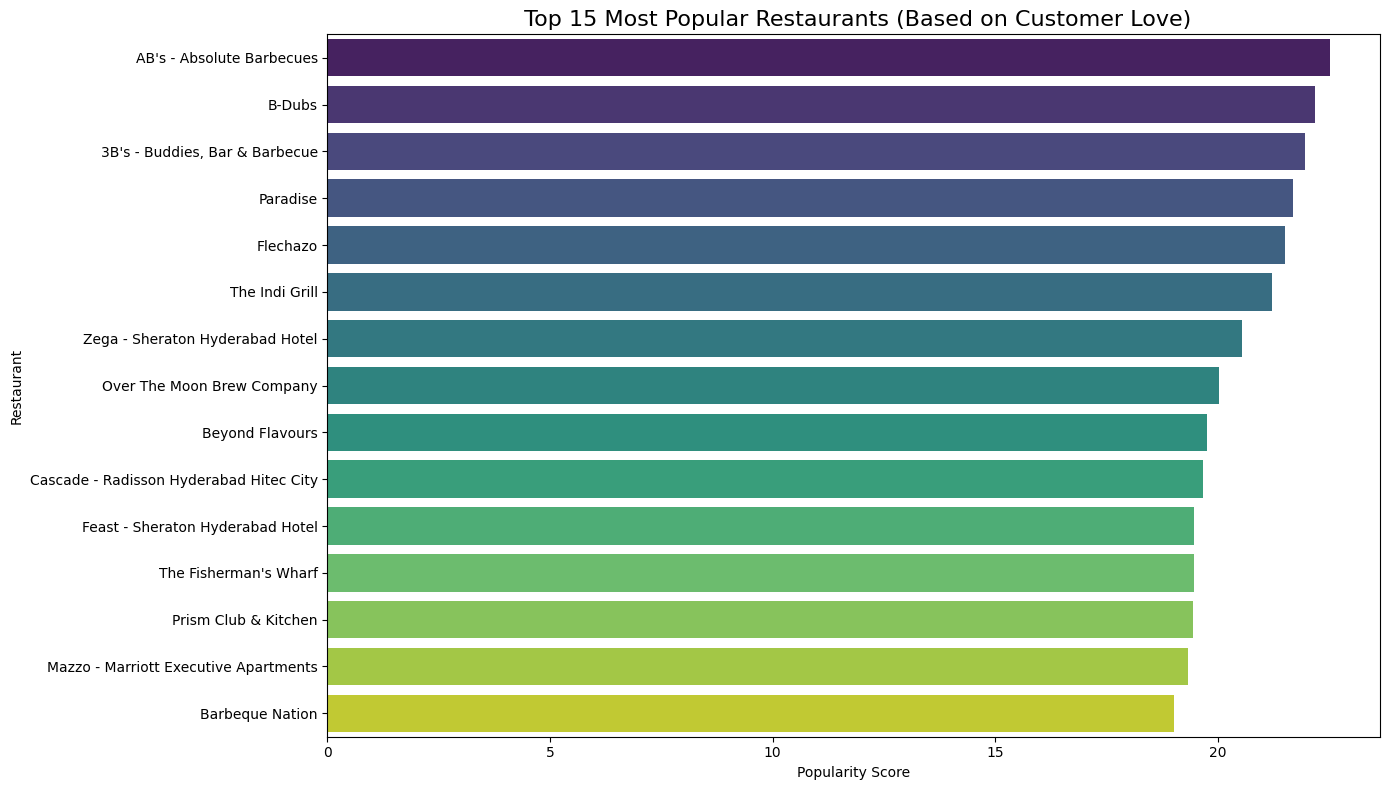

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your merged dataset
df = pd.read_csv("Zomato_Merged_Sentiment_Analysis.csv")

# Clean rating
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Group by restaurant to compute review count & avg rating
review_stats = df.groupby('Restaurant').agg({
    'Review': 'count',
    'Rating': 'mean'
}).reset_index()

review_stats.rename(columns={'Review': 'Num_Reviews', 'Rating': 'Avg_Rating'}, inplace=True)

# Calculate popularity score
review_stats['Popularity_Score'] = review_stats['Avg_Rating'] * np.log1p(review_stats['Num_Reviews'])

# Top 15 by popularity
top_customers = review_stats.sort_values(by='Popularity_Score', ascending=False).head(15)

# Show results
print(" Top 15 Restaurants Loved by Customers:")
print(top_customers[['Restaurant', 'Num_Reviews', 'Avg_Rating', 'Popularity_Score']])

# --- Visualization ---
plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_customers,
    x='Popularity_Score',
    y='Restaurant',
    palette='viridis'
)
plt.title(" Top 15 Most Popular Restaurants (Based on Customer Love)", fontsize=16)
plt.xlabel("Popularity Score")
plt.ylabel("Restaurant")
plt.tight_layout()
plt.show()


Accuracy: 0.8628829733802109

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.51      0.65       501
           1       0.86      0.98      0.91      1490

    accuracy                           0.86      1991
   macro avg       0.88      0.75      0.78      1991
weighted avg       0.87      0.86      0.85      1991



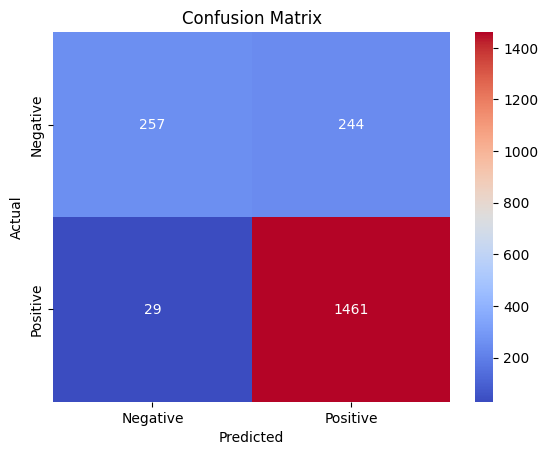

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Preprocessing
# Clean and keep only reviews with text and rating
merged_df = merged_df.dropna(subset=['Review', 'Rating'])
# Convert 'Rating' to numeric, forcing errors to NaN
merged_df['Rating'] = pd.to_numeric(merged_df['Rating'], errors='coerce')

# Drop rows where 'Rating' is NaN
merged_df = merged_df.dropna(subset=['Rating'])


# Create sentiment label: 1 if rating ≥ 3, else 0
merged_df['sentiment'] = merged_df['Rating'].apply(lambda x: 1 if x >= 3 else 0)

# 2. Text Vectorization
X = merged_df['Review']
y = merged_df['sentiment']

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_vec = tfidf.fit_transform(X)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

# 4. Naive Bayes Model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# 5. Predictions
y_pred = nb_model.predict(X_test)

# 6. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="coolwarm", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [26]:
 pip install --upgrade pip



   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------- ---------------------- 0.8/1.8 MB 5.6 MB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 4.8 MB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1


In [32]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('Zomato_Merged_Metadata_Reviews.csv')

# 2. Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# 3. Check available columns (for debug)
print("Columns:", df.columns.tolist())

# 4. Drop rows with nulls in important fields
required_cols = ['Review', 'Rating']
df = df.dropna(subset=required_cols)

# 5. Strip strings and clean rating
df['Review'] = df['Review'].astype(str).str.strip()
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# 6. Drop rows where rating couldn't convert to number
df = df.dropna(subset=['Rating'])

#  Optional: Add sentiment column (1 if rating ≥ 3, else 0)
df['sentiment'] = df['Rating'].apply(lambda x: 1 if x >= 3 else 0)

#  Optional: Add review length column
df['review_length'] = df['Review'].apply(lambda x: len(x))
df['word_count'] = df['Review'].apply(lambda x: len(x.split()))

#  Optional: Bucket ratings (1–2 = Low, 3 = Mid, 4–5 = High)
def bucket(rating):
    if rating < 3:
        return 'Low'
    elif rating == 3:
        return 'Mid'
    else:
        return 'High'

df['rating_bucket'] = df['Rating'].apply(bucket)

# Show a sample
df.head()


Columns: ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Links,Cost,Collections,Cuisines,Timings,sentiment,review_length,word_count,rating_bucket
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",5/25/2019 15:54,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",1,222,41,High
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",5/25/2019 14:20,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",1,144,27,High
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",5/24/2019 22:54,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",1,189,31,High
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",5/24/2019 22:11,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",1,148,28,High
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",5/24/2019 21:37,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",1,160,27,High


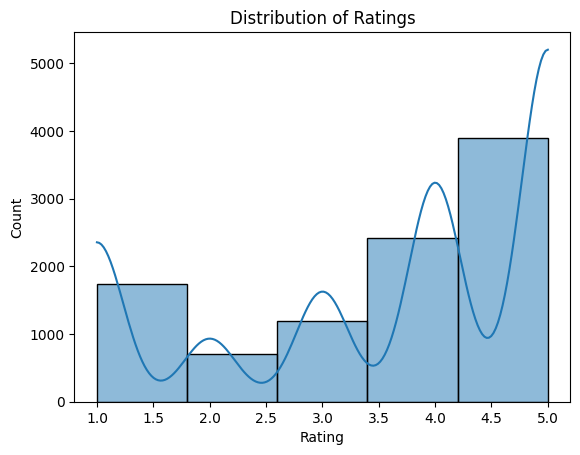

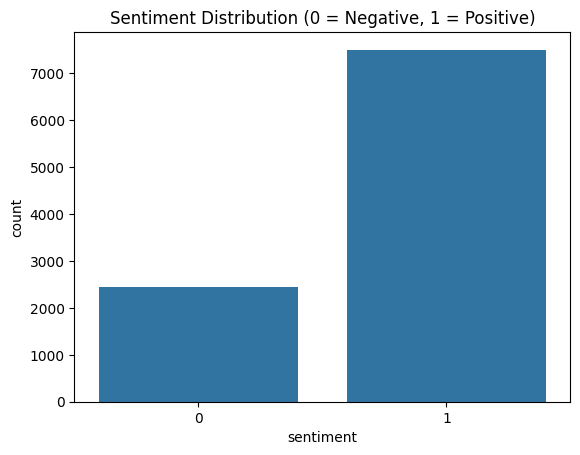

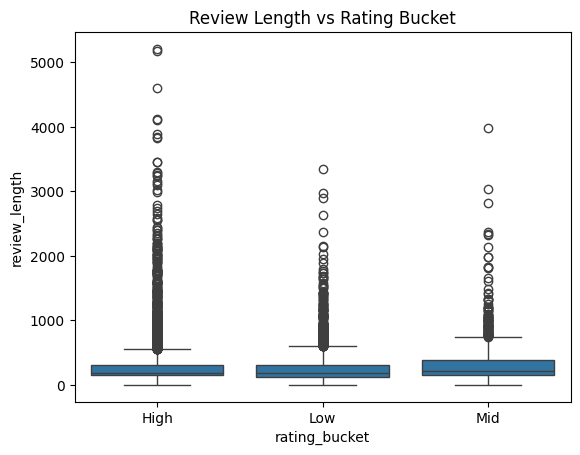

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of Ratings
sns.histplot(df['Rating'], bins=5, kde=True)
plt.title('Distribution of Ratings')
plt.show()

# Sentiment count
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution (0 = Negative, 1 = Positive)')
plt.show()

# Review Length vs Rating
sns.boxplot(x='rating_bucket', y='review_length', data=df)
plt.title('Review Length vs Rating Bucket')
plt.show()
